In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

# load the olivetti faces dataset
data = fetch_olivetti_faces()
X = data.data  # Flattened images
y = data.target  # Labels (person IDs)

print(X[0, :10])

[0.30991736 0.3677686  0.41735536 0.44214877 0.5289256  0.607438
 0.6570248  0.677686   0.69008267 0.6859504 ]


In [34]:
# shuffle the training data
shuffle_indices = np.random.permutation(len(X))
X = X[shuffle_indices]
y = y[shuffle_indices]

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(320, 4096) (80, 4096)


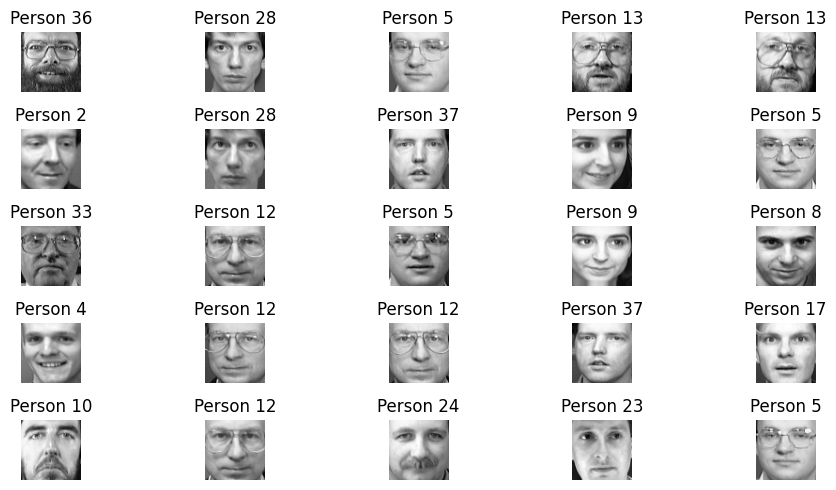

In [35]:
# visualize some sample images from the dataset
fig, axes = plt.subplots(5, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'Person {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [36]:
class FuzzyART:

    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5, learning_rate: float = 1.0, alpha: float = 0.001, complement: bool = True):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features * 2 if complement else num_features
        # β is a small positive constant (often β < 1)
        self.beta = learning_rate
        # α is a small positive constant used in the choice function.
        self.alpha = alpha
        # for each feature xi​, its complement (1−xi)​ is also included in the input vector
        self.complement = complement
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        # self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.weights = np.ones((self.max_clusters, self.num_features))

    def _complement_code(self, X: np.ndarray) -> np.ndarray:
        return np.concatenate([X, 1 - X])

    def _fuzzy_and(self, X: np.ndarray, W: np.ndarray) -> np.ndarray:
        return np.minimum(X, W)

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # Tj = ‖x ∧ Wj‖ / α + ‖Wj‖
        for j in range(self.num_clusters):
            activations[j] = np.sum(self._fuzzy_and(X, self.weights[j])) / (self.alpha + np.sum(self.weights[j]))
            print(f"Cluster {j}: activation={activations[j]:.4f}")
        
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # ‖x ∧ Wj‖ / ‖x‖ ≥ ρ
        fuzzy_and_norm = np.sum(self._fuzzy_and(X, self.weights[best_cluster]))
        if fuzzy_and_norm == 0:
            return False
        match_ratio = fuzzy_and_norm / np.sum(X)
        print(f"Cluster {best_cluster}: match_ratio={match_ratio:.4f}, vigilance={self.vigilance}")
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # wJ (new) = β(x ∧ wJ (old)) + (1 − β)wJ (old)
        new_wj = self.beta * self._fuzzy_and(X, self.weights[cluster_idx]) + (1 - self.beta) * self.weights[cluster_idx]
        self.weights[cluster_idx] = new_wj

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X

        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached. "
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            # self._update_weights(X, new_idx)
            self.weights[new_idx] = X.copy()
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return sorted_clusters[0]

    def get_weights(self) -> np.ndarray:
        return self.weights[:self.num_clusters]

In [38]:
net = FuzzyART(
    num_features=X_train.shape[1],
    max_clusters=4000,
    vigilance=0.84,
    learning_rate=0.6,
    alpha=0.01,
    complement=True
 )

cluster_assignments = np.full(len(X_train), -1, dtype=np.int32)
for i, x in enumerate(X_train):
    print(f"Training sample {i+1}/{len(X_train)}", end="\r")
    try:
        cluster_assignments[i] = net.train(x)
    except RuntimeError:
        cluster_assignments = cluster_assignments[:i]
        print(f"Stopped at sample {i}")
        break

print(f"Active clusters: {net.num_clusters}")
print(f"Trained samples: {len(cluster_assignments)}")

with open("weights_log.txt", "w") as log_file:
    weights = net.get_weights()
    for idx, w in enumerate(weights):
        log_file.write(f"Cluster {idx} weights: {w}\n")
        

Cluster 0: activation=0.8439
Cluster 0: match_ratio=0.8439, vigilance=0.84
Cluster 0: activation=0.9244
Cluster 0: match_ratio=0.8378, vigilance=0.84
Cluster 0: activation=0.8984
Cluster 1: activation=0.8687
Cluster 0: match_ratio=0.8143, vigilance=0.84
Cluster 0: activation=0.8686
Cluster 1: activation=0.8163
Cluster 2: activation=0.8047
Cluster 0: match_ratio=0.7873, vigilance=0.84
Cluster 0: activation=0.8914
Cluster 1: activation=0.8579
Cluster 2: activation=0.8390
Cluster 3: activation=0.8367
Cluster 0: match_ratio=0.8079, vigilance=0.84
Cluster 0: activation=0.9080
Cluster 1: activation=0.8833
Cluster 2: activation=0.8937
Cluster 3: activation=0.8356
Cluster 4: activation=0.8691
Cluster 0: match_ratio=0.8229, vigilance=0.84
Cluster 0: activation=0.9178
Cluster 1: activation=0.8653
Cluster 2: activation=0.8313
Cluster 3: activation=0.8277
Cluster 4: activation=0.8521
Cluster 5: activation=0.8431
Cluster 0: match_ratio=0.8318, vigilance=0.84
Cluster 0: activation=0.9358
Cluster 1: 

Total clusters found: 204


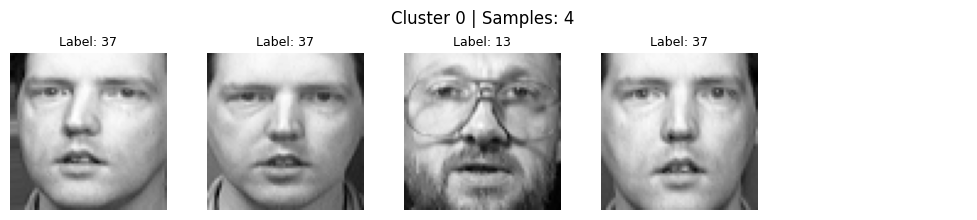

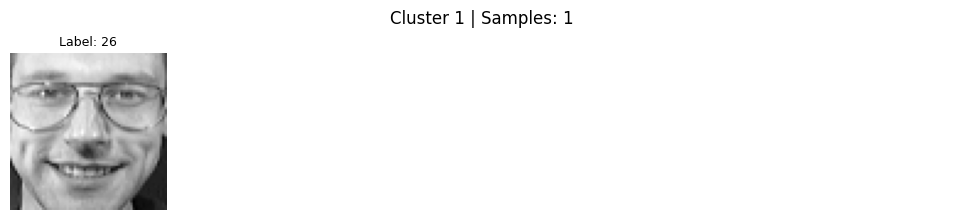

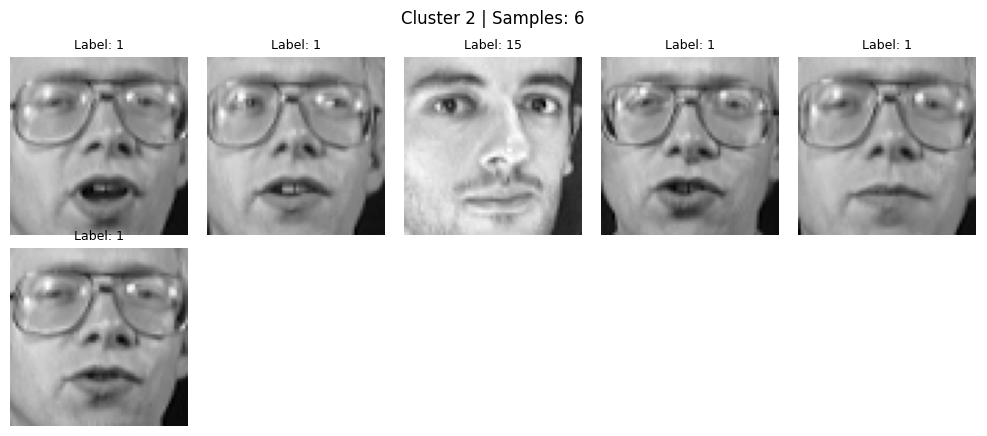

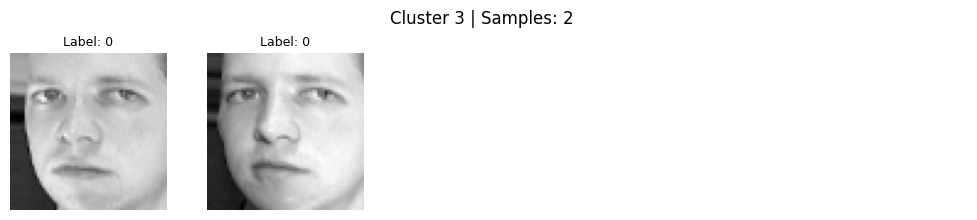

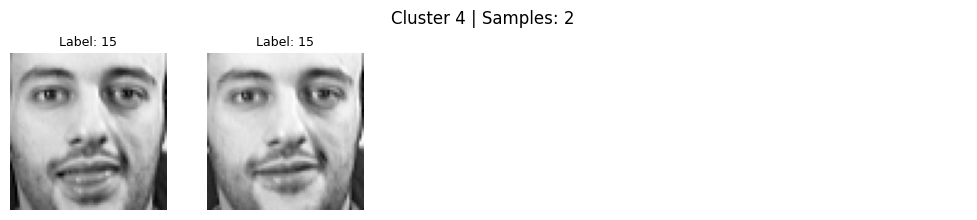

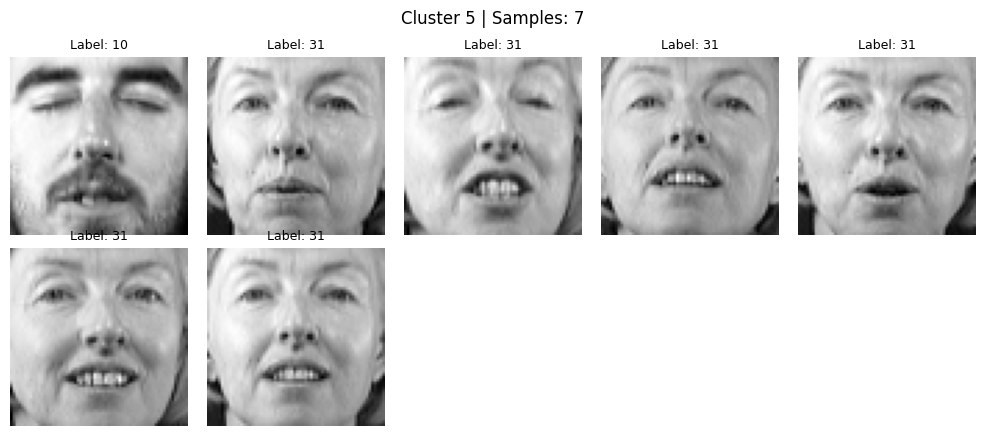

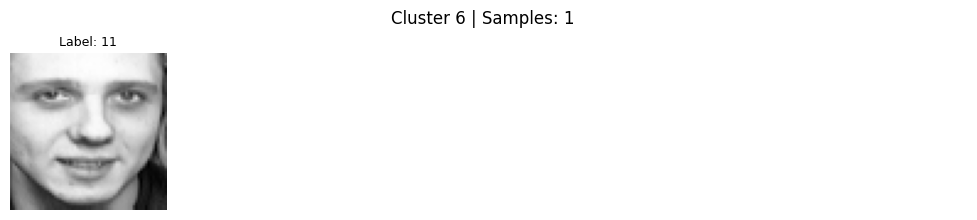

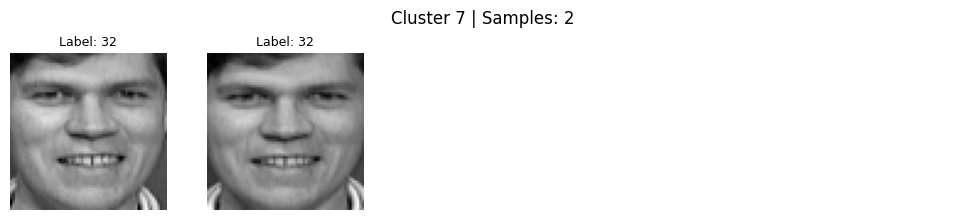

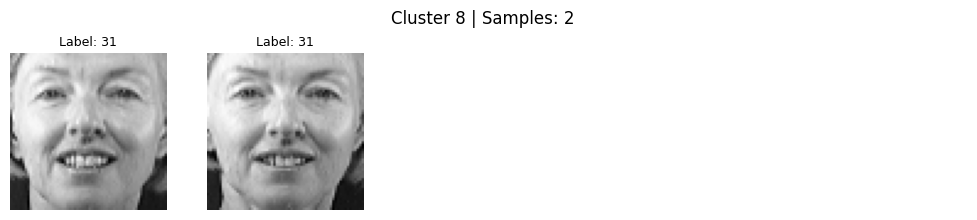

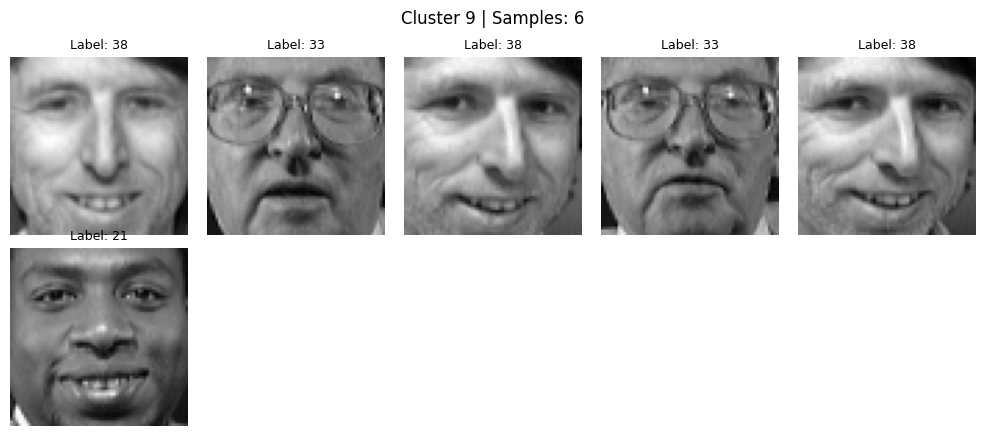

In [39]:
# Show image samples for each ART1 cluster
trained_n = len(cluster_assignments)
X_trained = X_train[:trained_n]
y_trained = y_train[:trained_n]

samples_per_cluster = 20
cluster_ids = np.unique(cluster_assignments)

print(f"Total clusters found: {len(cluster_ids)}")

for cluster_id in cluster_ids[:10]:
    idx = np.where(cluster_assignments == cluster_id)[0]
    if len(idx) == 0:
        continue

    # Pick up to N samples from this cluster (randomized for variety)
    n_show = min(samples_per_cluster, len(idx))
    show_idx = np.random.choice(idx, size=n_show, replace=False)

    cols = 5
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = np.array(axes).reshape(-1)

    for ax, sample_i in zip(axes, show_idx):
        ax.imshow(X_trained[sample_i].reshape(64, 64), cmap="gray")
        label_text = y_trained[sample_i]
        ax.set_title(f"Label: {label_text}", fontsize=9)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    fig.suptitle(f"Cluster {cluster_id} | Samples: {len(idx)}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [40]:
from collections import Counter

y_trained = y_train[:trained_n]

purities = []
cluster_label_map = {}

print("\nCluster purity analysis:")
for cid in cluster_ids:
    idx = np.where(cluster_assignments == cid)[0]
    label_counts = Counter(y_trained[idx])
    dominant = label_counts.most_common(1)[0]
    cluster_label_map[cid] = dominant[0]
    purity = dominant[1] / len(idx)
    purities.append(purity)
    print(f"Cluster {cid:2d}: {len(idx):5d} samples | dominant digit={dominant[0]} | purity={purity:.1%}")

# ponder overall accuracy by cluster size
weights = np.array([len(np.where(cluster_assignments == cid)[0]) for cid in cluster_ids])
accuracy = np.average(purities, weights=weights)
print(f"Overall accuracy: {accuracy:.1%}")


Cluster purity analysis:
Cluster  0:     4 samples | dominant digit=37 | purity=75.0%
Cluster  1:     1 samples | dominant digit=26 | purity=100.0%
Cluster  2:     6 samples | dominant digit=1 | purity=83.3%
Cluster  3:     2 samples | dominant digit=0 | purity=100.0%
Cluster  4:     2 samples | dominant digit=15 | purity=100.0%
Cluster  5:     7 samples | dominant digit=31 | purity=85.7%
Cluster  6:     1 samples | dominant digit=11 | purity=100.0%
Cluster  7:     2 samples | dominant digit=32 | purity=100.0%
Cluster  8:     2 samples | dominant digit=31 | purity=100.0%
Cluster  9:     6 samples | dominant digit=38 | purity=50.0%
Cluster 10:     5 samples | dominant digit=22 | purity=40.0%
Cluster 11:     1 samples | dominant digit=26 | purity=100.0%
Cluster 12:     4 samples | dominant digit=7 | purity=100.0%
Cluster 13:     1 samples | dominant digit=17 | purity=100.0%
Cluster 14:     1 samples | dominant digit=3 | purity=100.0%
Cluster 15:     1 samples | dominant digit=9 | purity

Cluster 0: activation=0.9236
Cluster 1: activation=0.8642
Cluster 2: activation=0.8776
Cluster 3: activation=0.8547
Cluster 4: activation=0.8326
Cluster 5: activation=0.8811
Cluster 6: activation=0.8510
Cluster 7: activation=0.8604
Cluster 8: activation=0.8514
Cluster 9: activation=0.8892
Cluster 10: activation=0.9220
Cluster 11: activation=0.8712
Cluster 12: activation=0.8208
Cluster 13: activation=0.8370
Cluster 14: activation=0.8736
Cluster 15: activation=0.8811
Cluster 16: activation=0.8661
Cluster 17: activation=0.8797
Cluster 18: activation=0.8902
Cluster 19: activation=0.8612
Cluster 20: activation=0.8545
Cluster 21: activation=0.8508
Cluster 22: activation=0.8219
Cluster 23: activation=0.9374
Cluster 24: activation=0.8512
Cluster 25: activation=0.8688
Cluster 26: activation=0.9043
Cluster 27: activation=0.9105
Cluster 28: activation=0.9616
Cluster 29: activation=0.9062
Cluster 30: activation=0.8774
Cluster 31: activation=0.8897
Cluster 32: activation=0.8777
Cluster 33: activati

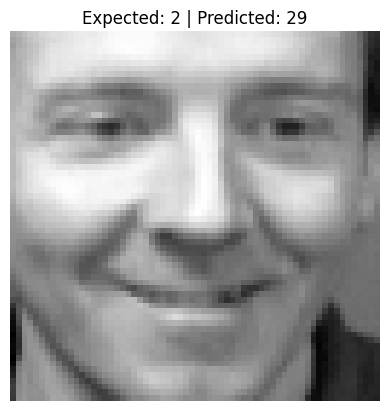

Cluster 0: activation=0.9279
Cluster 1: activation=0.8801
Cluster 2: activation=0.9377
Cluster 3: activation=0.8906
Cluster 4: activation=0.8933
Cluster 5: activation=0.9368
Cluster 6: activation=0.8606
Cluster 7: activation=0.8504
Cluster 8: activation=0.8788
Cluster 9: activation=0.8413
Cluster 10: activation=0.9513
Cluster 11: activation=0.8776
Cluster 12: activation=0.8824
Cluster 13: activation=0.8915
Cluster 14: activation=0.8735
Cluster 15: activation=0.8828
Cluster 16: activation=0.8487
Cluster 17: activation=0.8826
Cluster 18: activation=0.8775
Cluster 19: activation=0.8502
Cluster 20: activation=0.8909
Cluster 21: activation=0.8755
Cluster 22: activation=0.9248
Cluster 23: activation=0.9131
Cluster 24: activation=0.8020
Cluster 25: activation=0.8835
Cluster 26: activation=0.9395
Cluster 27: activation=0.8686
Cluster 28: activation=0.8786
Cluster 29: activation=0.8967
Cluster 30: activation=0.8996
Cluster 31: activation=0.8414
Cluster 32: activation=0.8598
Cluster 33: activati

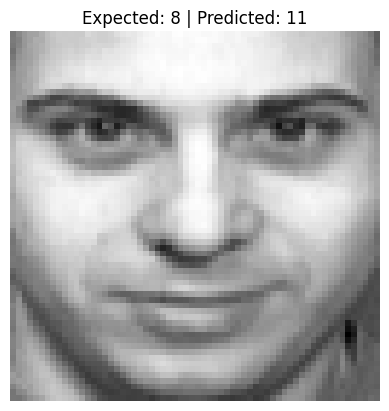

Cluster 0: activation=0.9160
Cluster 1: activation=0.8716
Cluster 2: activation=0.9088
Cluster 3: activation=0.8424
Cluster 4: activation=0.8858
Cluster 5: activation=0.9349
Cluster 6: activation=0.8382
Cluster 7: activation=0.8410
Cluster 8: activation=0.8906
Cluster 9: activation=0.8544
Cluster 10: activation=0.9170
Cluster 11: activation=0.8661
Cluster 12: activation=0.8627
Cluster 13: activation=0.8534
Cluster 14: activation=0.8609
Cluster 15: activation=0.8580
Cluster 16: activation=0.8795
Cluster 17: activation=0.8845
Cluster 18: activation=0.8490
Cluster 19: activation=0.8422
Cluster 20: activation=0.8561
Cluster 21: activation=0.8618
Cluster 22: activation=0.8518
Cluster 23: activation=0.8857
Cluster 24: activation=0.8209
Cluster 25: activation=0.8598
Cluster 26: activation=0.9189
Cluster 27: activation=0.8531
Cluster 28: activation=0.8724
Cluster 29: activation=0.8769
Cluster 30: activation=0.8657
Cluster 31: activation=0.8423
Cluster 32: activation=0.8495
Cluster 33: activati

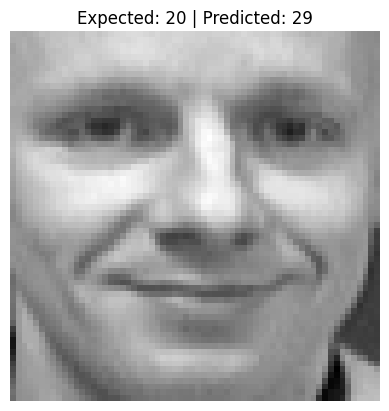

Cluster 0: activation=0.8756
Cluster 1: activation=0.8221
Cluster 2: activation=0.8691
Cluster 3: activation=0.8739
Cluster 4: activation=0.8832
Cluster 5: activation=0.8868
Cluster 6: activation=0.8476
Cluster 7: activation=0.7747
Cluster 8: activation=0.8220
Cluster 9: activation=0.7418
Cluster 10: activation=0.9489
Cluster 11: activation=0.8228
Cluster 12: activation=0.8414
Cluster 13: activation=0.8874
Cluster 14: activation=0.8316
Cluster 15: activation=0.8106
Cluster 16: activation=0.7944
Cluster 17: activation=0.8098
Cluster 18: activation=0.8390
Cluster 19: activation=0.7733
Cluster 20: activation=0.8859
Cluster 21: activation=0.8286
Cluster 22: activation=0.8795
Cluster 23: activation=0.8310
Cluster 24: activation=0.7234
Cluster 25: activation=0.8298
Cluster 26: activation=0.8946
Cluster 27: activation=0.7978
Cluster 28: activation=0.8119
Cluster 29: activation=0.8240
Cluster 30: activation=0.8551
Cluster 31: activation=0.7679
Cluster 32: activation=0.7787
Cluster 33: activati

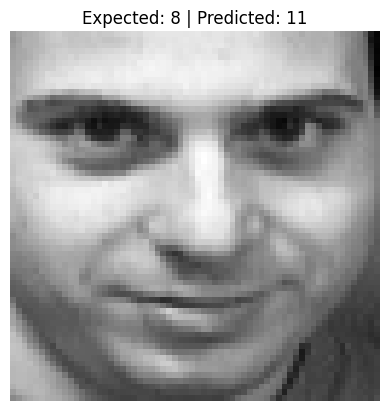

Cluster 0: activation=0.9311
Cluster 1: activation=0.8786
Cluster 2: activation=0.9582
Cluster 3: activation=0.8516
Cluster 4: activation=0.8748
Cluster 5: activation=0.9581
Cluster 6: activation=0.8431
Cluster 7: activation=0.8682
Cluster 8: activation=0.8876
Cluster 9: activation=0.8821
Cluster 10: activation=0.9292
Cluster 11: activation=0.8834
Cluster 12: activation=0.8833
Cluster 13: activation=0.8699
Cluster 14: activation=0.8913
Cluster 15: activation=0.8838
Cluster 16: activation=0.9057
Cluster 17: activation=0.9183
Cluster 18: activation=0.8622
Cluster 19: activation=0.8807
Cluster 20: activation=0.8709
Cluster 21: activation=0.8776
Cluster 22: activation=0.8714
Cluster 23: activation=0.9187
Cluster 24: activation=0.8227
Cluster 25: activation=0.8779
Cluster 26: activation=0.9266
Cluster 27: activation=0.8790
Cluster 28: activation=0.8798
Cluster 29: activation=0.9164
Cluster 30: activation=0.8900
Cluster 31: activation=0.8532
Cluster 32: activation=0.8930
Cluster 33: activati

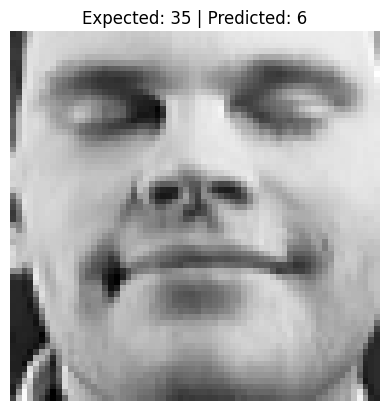

Cluster 0: activation=0.9416
Cluster 1: activation=0.8697
Cluster 2: activation=0.9064
Cluster 3: activation=0.8617
Cluster 4: activation=0.8650
Cluster 5: activation=0.9068
Cluster 6: activation=0.8788
Cluster 7: activation=0.8766
Cluster 8: activation=0.8584
Cluster 9: activation=0.8803
Cluster 10: activation=0.9477
Cluster 11: activation=0.8765
Cluster 12: activation=0.8603
Cluster 13: activation=0.8778
Cluster 14: activation=0.8859
Cluster 15: activation=0.8918
Cluster 16: activation=0.8663
Cluster 17: activation=0.8874
Cluster 18: activation=0.8889
Cluster 19: activation=0.8729
Cluster 20: activation=0.8855
Cluster 21: activation=0.8545
Cluster 22: activation=0.8622
Cluster 23: activation=0.9304
Cluster 24: activation=0.8339
Cluster 25: activation=0.8772
Cluster 26: activation=0.9240
Cluster 27: activation=0.9121
Cluster 28: activation=0.9447
Cluster 29: activation=0.9168
Cluster 30: activation=0.8980
Cluster 31: activation=0.8773
Cluster 32: activation=0.8808
Cluster 33: activati

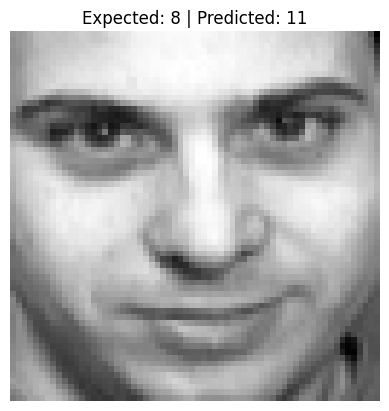

Cluster 0: activation=0.9140
Cluster 1: activation=0.8565
Cluster 2: activation=0.9353
Cluster 3: activation=0.8019
Cluster 4: activation=0.8318
Cluster 5: activation=0.9173
Cluster 6: activation=0.8201
Cluster 7: activation=0.8747
Cluster 8: activation=0.8659
Cluster 9: activation=0.9245
Cluster 10: activation=0.8680
Cluster 11: activation=0.8611
Cluster 12: activation=0.8924
Cluster 13: activation=0.8338
Cluster 14: activation=0.8434
Cluster 15: activation=0.8814
Cluster 16: activation=0.8970
Cluster 17: activation=0.9179
Cluster 18: activation=0.8217
Cluster 19: activation=0.8998
Cluster 20: activation=0.8216
Cluster 21: activation=0.8439
Cluster 22: activation=0.8494
Cluster 23: activation=0.8946
Cluster 24: activation=0.8347
Cluster 25: activation=0.8544
Cluster 26: activation=0.8842
Cluster 27: activation=0.8673
Cluster 28: activation=0.8891
Cluster 29: activation=0.8972
Cluster 30: activation=0.8543
Cluster 31: activation=0.8575
Cluster 32: activation=0.8983
Cluster 33: activati

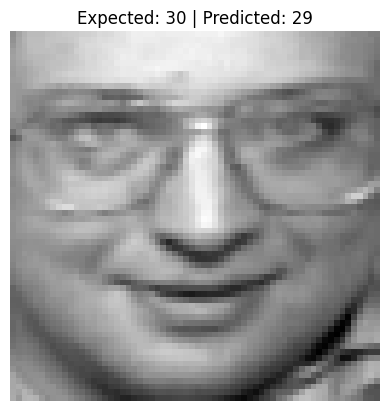

Cluster 0: activation=0.8573
Cluster 1: activation=0.8283
Cluster 2: activation=0.8593
Cluster 3: activation=0.8394
Cluster 4: activation=0.8680
Cluster 5: activation=0.8914
Cluster 6: activation=0.8081
Cluster 7: activation=0.7810
Cluster 8: activation=0.8402
Cluster 9: activation=0.7700
Cluster 10: activation=0.9105
Cluster 11: activation=0.8248
Cluster 12: activation=0.8255
Cluster 13: activation=0.8397
Cluster 14: activation=0.8216
Cluster 15: activation=0.8210
Cluster 16: activation=0.8176
Cluster 17: activation=0.8162
Cluster 18: activation=0.8152
Cluster 19: activation=0.7834
Cluster 20: activation=0.8432
Cluster 21: activation=0.8547
Cluster 22: activation=0.8471
Cluster 23: activation=0.8370
Cluster 24: activation=0.7436
Cluster 25: activation=0.8287
Cluster 26: activation=0.9163
Cluster 27: activation=0.7942
Cluster 28: activation=0.8104
Cluster 29: activation=0.8219
Cluster 30: activation=0.8307
Cluster 31: activation=0.7803
Cluster 32: activation=0.7951
Cluster 33: activati

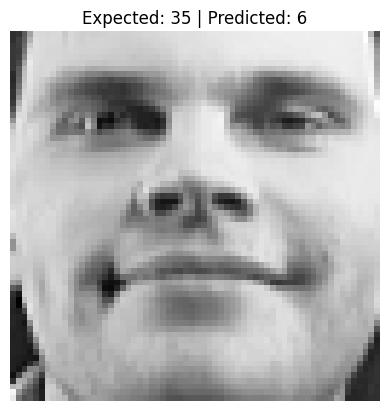

Cluster 0: activation=0.9156
Cluster 1: activation=0.8700
Cluster 2: activation=0.9339
Cluster 3: activation=0.8139
Cluster 4: activation=0.8377
Cluster 5: activation=0.9097
Cluster 6: activation=0.8613
Cluster 7: activation=0.8240
Cluster 8: activation=0.8547
Cluster 9: activation=0.8318
Cluster 10: activation=0.8767
Cluster 11: activation=0.8573
Cluster 12: activation=0.9414
Cluster 13: activation=0.8647
Cluster 14: activation=0.8305
Cluster 15: activation=0.8338
Cluster 16: activation=0.8224
Cluster 17: activation=0.8653
Cluster 18: activation=0.8197
Cluster 19: activation=0.8331
Cluster 20: activation=0.8451
Cluster 21: activation=0.8029
Cluster 22: activation=0.8784
Cluster 23: activation=0.8534
Cluster 24: activation=0.8084
Cluster 25: activation=0.8661
Cluster 26: activation=0.8612
Cluster 27: activation=0.8430
Cluster 28: activation=0.8531
Cluster 29: activation=0.8685
Cluster 30: activation=0.8478
Cluster 31: activation=0.7880
Cluster 32: activation=0.8284
Cluster 33: activati

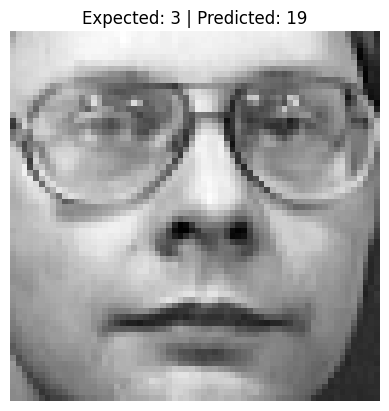

Cluster 0: activation=0.9648
Cluster 1: activation=0.8977
Cluster 2: activation=0.9338
Cluster 3: activation=0.8184
Cluster 4: activation=0.8670
Cluster 5: activation=0.9365
Cluster 6: activation=0.8658
Cluster 7: activation=0.8814
Cluster 8: activation=0.9002
Cluster 9: activation=0.9102
Cluster 10: activation=0.9162
Cluster 11: activation=0.8982
Cluster 12: activation=0.9051
Cluster 13: activation=0.8626
Cluster 14: activation=0.8817
Cluster 15: activation=0.9023
Cluster 16: activation=0.8981
Cluster 17: activation=0.9205
Cluster 18: activation=0.8570
Cluster 19: activation=0.8987
Cluster 20: activation=0.8549
Cluster 21: activation=0.8479
Cluster 22: activation=0.8497
Cluster 23: activation=0.9033
Cluster 24: activation=0.8683
Cluster 25: activation=0.9019
Cluster 26: activation=0.9038
Cluster 27: activation=0.9064
Cluster 28: activation=0.9257
Cluster 29: activation=0.9176
Cluster 30: activation=0.8782
Cluster 31: activation=0.8713
Cluster 32: activation=0.9049
Cluster 33: activati

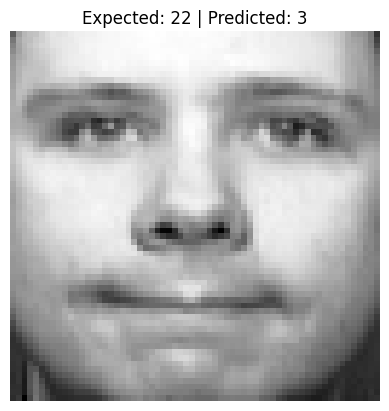

Cluster 0: activation=0.9065
Cluster 1: activation=0.8404
Cluster 2: activation=0.8834
Cluster 3: activation=0.9099
Cluster 4: activation=0.8679
Cluster 5: activation=0.8832
Cluster 6: activation=0.8590
Cluster 7: activation=0.8347
Cluster 8: activation=0.8401
Cluster 9: activation=0.8136
Cluster 10: activation=0.9501
Cluster 11: activation=0.8465
Cluster 12: activation=0.8305
Cluster 13: activation=0.8905
Cluster 14: activation=0.8597
Cluster 15: activation=0.8461
Cluster 16: activation=0.8046
Cluster 17: activation=0.8419
Cluster 18: activation=0.8868
Cluster 19: activation=0.8094
Cluster 20: activation=0.8992
Cluster 21: activation=0.8537
Cluster 22: activation=0.9053
Cluster 23: activation=0.9139
Cluster 24: activation=0.7890
Cluster 25: activation=0.8515
Cluster 26: activation=0.9235
Cluster 27: activation=0.8499
Cluster 28: activation=0.8696
Cluster 29: activation=0.8786
Cluster 30: activation=0.8952
Cluster 31: activation=0.8195
Cluster 32: activation=0.8235
Cluster 33: activati

In [41]:
def predict(net, cluster_label_map, X):
    cluster_id = net.predict(X)
    if cluster_id == -1:
        return None  # no matching cluster found
    return cluster_label_map[cluster_id]


def display_image_and_prediction(image, expected, predicted):
    plt.imshow(image.reshape(64, 64), cmap="gray")
    plt.title(f"Expected: {expected} | Predicted: {predicted}")
    plt.axis("off")
    plt.show()


accuracy_count = 0
number_to_test = min(10000, len(X_test))
mismatch_count = 0

for i, X_ in enumerate(X_test[:number_to_test]):
    predicted_digit = predict(net, cluster_label_map, X_)
    actual_digit = y_test[i]

    if predicted_digit == actual_digit:
        accuracy_count += 1

    if predicted_digit != actual_digit:
        if mismatch_count >= 10:
            continue
        mismatch_count += 1
        print(f"Mismatch at sample {i}: expected {actual_digit}, predicted {predicted_digit}")
        display_image_and_prediction(X_, actual_digit, predicted_digit)

print(f"Correct predictions: {accuracy_count} out of {number_to_test}")
print(f"Accuracy: {accuracy_count / number_to_test * 100:.2f}%")